# Lesson 2 — Homework

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/djnzx/ida-practice-3d/blob/main/practice/2/2-homework.ipynb)

**Estimated time: 3-4 hours.**

## How to work through this

Each task gives a function signature and a docstring stating exactly what
the function must return. Replace `raise NotImplementedError` with your
implementation; the cell after it asserts the behaviour.

**A failing assert is information, not a grade.** Read it, fix the
function, re-run.

The written questions are marked and they carry the real learning
objective. Each asks you to **run something both ways and explain the
difference**, using numbers you produced. One sentence will not be enough.

Every function you need is demonstrated in `2-practice.ipynb`, and each task
names the section. You should not need any other documentation.

## Before you submit

**Runtime → Restart and run all must complete without error** with every
assert passing. Then **File → Download → Download .ipynb**, rename the file to
`2-homework-results.ipynb`, and commit it to your fork under
`practice/2/`. Keep the outputs in the file; do not clear them.
The full procedure is in `practice/README.md` §8.

## 1. Setup

In [1]:
import sys

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 20250919
rng = np.random.default_rng(SEED)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (7.0, 4.5)
plt.rcParams["figure.dpi"] = 110

print("python", sys.version.split()[0], "| pandas", pd.__version__, "| seaborn", sns.__version__)

python 3.13.15 | pandas 2.2.3 | seaborn 0.13.2


In [2]:
titanic = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/titanic.csv"
)
wine = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/wine.csv"
)
bikes = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/bike_sharing_hourly.csv"
)

print("titanic", titanic.shape, "| wine", wine.shape, "| bikes", bikes.shape)

titanic (891, 12) | wine (178, 14) | bikes (17379, 17)


## 2. Task 1 — A missingness report

Mechanical.

*see Practice 2 §5.1*

In [3]:
def missing_report(frame):
    """Return a DataFrame describing the missing values of `frame`.

    One row per column that has at least one missing value. Columns with
    no missing values are excluded entirely.

    Two columns, in this order:
        'missing'  the count of missing values, an integer
        'percent'  the percentage of rows missing, 0-100, rounded to 2 dp

    Sorted by 'missing', descending. The index is the original column name.
    """
    missing = frame.isna().sum()
    missing = missing[missing > 0]

    report = pd.DataFrame({
        "missing": missing,
        "percent": (missing / len(frame) * 100).round(2),
    })

    return report.sort_values("missing", ascending=False)

In [4]:
_report = missing_report(titanic)

assert list(_report.columns) == ["missing", "percent"], f"columns wrong: {list(_report.columns)}"
assert len(_report) == 3, f"Titanic has three columns with gaps, you reported {len(_report)}"
assert list(_report.index) == ["Cabin", "Age", "Embarked"], \
    f"wrong columns or wrong order: {list(_report.index)}"
assert _report.loc["Cabin", "missing"] == 687
assert _report.loc["Age", "missing"] == 177
assert _report.loc["Embarked", "missing"] == 2
assert np.isclose(_report.loc["Age", "percent"], 19.87, atol=0.01), \
    f"percent should be 100 * 177/891 = 19.87, got {_report.loc['Age', 'percent']}"

# a frame with no gaps produces an empty report, not an error
assert len(missing_report(wine)) == 0, "wine.csv has no missing values"

print(_report)
print("\nTask 1 passed.")

          missing  percent
Cabin         687  77.1000
Age           177  19.8700
Embarked        2   0.2200

Task 1 passed.


## 3. Task 2 — Label against position

Mechanical, and the trap is real. After a sort, `.loc` and `.iloc` answer
different questions.

*see Practice 2 §4*

In [5]:
def first_and_labelled(frame, sort_column, label):
    """Sort `frame` by `sort_column` descending, then return a tuple:

        (top_row, labelled_row)

    top_row       the row now in FIRST POSITION, as a Series
    labelled_row  the row whose INDEX LABEL equals `label`, as a Series

    Do not reset the index. Both must come from the sorted frame.
    """
    sorted_frame = frame.sort_values(sort_column, ascending=False)

    top_row = sorted_frame.iloc[0]
    labelled_row = sorted_frame.loc[label]

    return top_row, labelled_row

In [6]:
_top, _labelled = first_and_labelled(titanic, "Fare", 0)

assert isinstance(_top, pd.Series) and isinstance(_labelled, pd.Series)
assert np.isclose(_top["Fare"], 512.3292), \
    f"the highest fare is 512.3292, you returned {_top['Fare']}"
assert _labelled["Name"] == "Braund, Mr. Owen Harris", \
    f"label 0 is Braund, you returned {_labelled['Name']}"
assert np.isclose(_labelled["Fare"], 7.25)
assert _top["Name"] != _labelled["Name"], \
    "position 0 and label 0 must be different passengers after sorting"

print("position 0 after sorting:", _top["Name"], "| fare", round(_top["Fare"], 2))
print("label 0 after sorting   :", _labelled["Name"], "| fare", round(_labelled["Fare"], 2))
print("\nTask 2 passed.")

position 0 after sorting: Cardeza, Mr. Thomas Drake Martinez | fare 512.33
label 0 after sorting   : Braund, Mr. Owen Harris | fare 7.25

Task 2 passed.


## 4. Task 3 — Group-wise imputation, without the chained-assignment bug

Applied. Fill missing ages with the median of the passenger's
`(Pclass, Sex)` group, and do it without triggering a
`SettingWithCopyWarning`.

*see Practice 2 §4.2, §5.4 and §6.3*

In [7]:
def fill_age_by_group(frame):
    """Return a COPY of `frame` with missing 'Age' filled by the median age
    of the passenger's (Pclass, Sex) group.

    The argument must not be modified.
    The returned frame must have no missing 'Age'.
    Use groupby(...).transform(...), not a loop, and not agg.
    """
    group_median = frame.groupby(["Pclass", "Sex"])["Age"].transform("median")

    result = frame.copy()
    result["Age"] = result["Age"].fillna(group_median)

    return result

In [8]:
import warnings

_before_missing = int(titanic["Age"].isna().sum())

with warnings.catch_warnings():
    warnings.simplefilter("error")          # any pandas warning becomes an exception
    _filled = fill_age_by_group(titanic)

assert int(titanic["Age"].isna().sum()) == _before_missing, "the argument was modified"
assert int(_filled["Age"].isna().sum()) == 0, "some ages are still missing"
assert len(_filled) == len(titanic), "rows were added or lost"

# The ages that were already present must be untouched.
_present = titanic["Age"].notna()
assert np.allclose(_filled.loc[_present, "Age"], titanic.loc[_present, "Age"]), \
    "existing ages were altered"

# A filled passenger must receive their own group's median, not the global one.
_a_gap = titanic.index[titanic["Age"].isna()][0]
_pclass, _sex = titanic.loc[_a_gap, "Pclass"], titanic.loc[_a_gap, "Sex"]
_expected = titanic[(titanic["Pclass"] == _pclass) & (titanic["Sex"] == _sex)]["Age"].median()
assert np.isclose(_filled.loc[_a_gap, "Age"], _expected), \
    f"passenger {_a_gap} got {_filled.loc[_a_gap, 'Age']}, expected group median {_expected}"

print(f"filled {_before_missing} ages; std went from "
      f"{titanic['Age'].std():.4f} to {_filled['Age'].std():.4f}")
print("Task 3 passed.")

filled 177 ages; std went from 14.5265 to 13.3044
Task 3 passed.


## 5. Task 4 — Four imputations, four distributions

Applied.

*see Practice 2 §5.4*

In [9]:
def compare_imputations(frame, column="Age"):
    """Return a DataFrame comparing four ways of handling missing values.

    Index, exactly these four labels in this order:
        'dropna', 'mean', 'median', 'group_median'

    Columns, in this order: 'n', 'mean', 'median', 'std'
        n       number of non-missing values after the strategy is applied
        mean    the mean of the resulting values
        median  the median
        std     the standard deviation (pandas default, ddof=1)

    'group_median' fills with the median of the (Pclass, Sex) group.
    """
    series = frame[column]

    dropna = series.dropna()

    mean_filled = series.fillna(series.mean())
    median_filled = series.fillna(series.median())

    group_median = frame.groupby(["Pclass", "Sex"])[column].transform("median")
    group_filled = series.fillna(group_median)

    data = {
        "dropna": dropna,
        "mean": mean_filled,
        "median": median_filled,
        "group_median": group_filled,
    }

    rows = {}

    for name, values in data.items():
        rows[name] = {
            "n": values.notna().sum(),
            "mean": values.mean(),
            "median": values.median(),
            "std": values.std(),
        }

    return pd.DataFrame(rows).T[["n", "mean", "median", "std"]]

In [10]:
_comparison = compare_imputations(titanic)

assert list(_comparison.index) == ["dropna", "mean", "median", "group_median"]
assert list(_comparison.columns) == ["n", "mean", "median", "std"]
assert _comparison.loc["dropna", "n"] == 714, "dropna keeps the 714 recorded ages"
assert _comparison.loc["mean", "n"] == 891, "filling keeps all 891 rows"

# Filling with the mean preserves the mean exactly and shrinks the spread.
assert np.isclose(_comparison.loc["mean", "mean"], titanic["Age"].mean()), \
    "filling with the mean must leave the mean unchanged"
assert _comparison.loc["mean", "std"] < _comparison.loc["dropna", "std"], \
    "stacking 177 rows on one value must reduce the standard deviation"

# The group-wise fill distorts the spread less than a single constant does.
assert _comparison.loc["group_median", "std"] > _comparison.loc["mean", "std"], \
    "the group-wise fill should preserve more of the spread than a constant fill"

print(_comparison.round(4))
print("\nTask 4 passed.")

                    n    mean  median     std
dropna       714.0000 29.6991 28.0000 14.5265
mean         891.0000 29.6991 29.6991 13.0020
median       891.0000 29.3616 28.0000 13.0197
group_median 891.0000 29.1124 26.0000 13.3044

Task 4 passed.


### Question 1 — choosing an imputation

Using the table you just produced, and a histogram of each of the four
resulting distributions:

**(a)** Filling with the mean leaves the mean **exactly** unchanged and
still damages the data. What quantity did it damage, by how much, and why
does preserving the mean not make the fill harmless?

**(b)** Compare `dropna` with the three fills. Dropping loses 177 rows,
20 % of the data. Under what condition about *why* the values are missing
is dropping unbiased, and is that condition plausible for Titanic's `Age`?
Name the MCAR / MAR / MNAR category you think applies and give your
evidence.

**(c)** You must pick one strategy and defend it to a reviewer. Pick one
and write the defence in three sentences.

In [11]:
# Space for the code that supports your answer.
comparison = compare_imputations(titanic)

print(comparison)

print("\nMissing Age by Pclass and Sex:")
print(
    titanic.groupby(["Pclass", "Sex"])["Age"]
    .agg(["count", "mean", "median"])
)

                    n    mean  median     std
dropna       714.0000 29.6991 28.0000 14.5265
mean         891.0000 29.6991 29.6991 13.0020
median       891.0000 29.3616 28.0000 13.0197
group_median 891.0000 29.1124 26.0000 13.3044

Missing Age by Pclass and Sex:
               count    mean  median
Pclass Sex                          
1      female     85 34.6118 35.0000
       male      101 41.2814 40.0000
2      female     74 28.7230 28.0000
       male       99 30.7407 30.0000
3      female    102 21.7500 21.5000
       male      253 26.5076 25.0000


**Your answer:**

(a) Заповнення пропусків середнім залишає середнє значення незмінним — 29.6991, але зменшує стандартне відхилення з 14.5265 до 13.0020. Це відбувається тому, що всі 177 пропущених значень замінюються одним числом 29.6991, через що зменшується варіативність і виникає штучне скупчення значень біля середнього. Тому збереження середнього не означає, що розподіл даних залишився незмінним.
(b) При dropna ми втрачаємо 177 із 891 рядків, тобто приблизно 20% спостережень. Результати за Pclass і Sex показують суттєві відмінності медіанного віку: від 21.5 для жінок 3-го класу до 40 для чоловіків 1-го класу. Тому припущення, що пропуски не залежать від інших характеристик, є слабким; для Age я вважаю MAR більш правдоподібним, оскільки пропуски можуть бути пов'язані з такими спостережуваними характеристиками, як Pclass і Sex.
(c) Я б обрав group_median. Він зберігає всі 891 спостереження та враховує відмінності між групами Pclass і Sex, на відміну від глобального середнього або медіани. Крім того, його стандартне відхилення 13.3044 вище, ніж після глобального заповнення середнім (13.0020), тобто він краще зберігає варіативність даних.

## 6. Task 5 — The IQR rule

Applied. Implement the rule behind a boxplot's whiskers.

*see Practice 2 §10.4*

In [12]:
def iqr_outliers(series, multiplier=1.5):
    """Flag the values of `series` outside the 1.5 x IQR fences.

    Q1 and Q3 are the 25th and 75th percentiles; IQR = Q3 - Q1.
    The fences are Q1 - multiplier*IQR and Q3 + multiplier*IQR.
    A value strictly outside either fence is an outlier.

    Missing values are never outliers.

    Return a dict with exactly these five keys:
        'q1', 'q3', 'lower', 'upper'   the four numbers, as floats
        'mask'  a boolean Series aligned to `series`, True where outlying
    """
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - multiplier * iqr
    upper = q3 + multiplier * iqr

    mask = (series < lower) | (series > upper)
    mask = mask.fillna(False)

    return {
        "q1": float(q1),
        "q3": float(q3),
        "lower": float(lower),
        "upper": float(upper),
        "mask": mask,
    }

In [13]:
_fare = iqr_outliers(titanic["Fare"], multiplier=1.5)

assert set(_fare) == {"q1", "q3", "lower", "upper", "mask"}
assert np.isclose(_fare["q1"], 7.9104, atol=1e-3), f"Q1 wrong: {_fare['q1']}"
assert np.isclose(_fare["q3"], 31.0, atol=1e-6), f"Q3 wrong: {_fare['q3']}"
assert np.isclose(_fare["upper"], 65.6344, atol=1e-3), f"upper fence wrong: {_fare['upper']}"
assert _fare["mask"].dtype == bool
assert int(_fare["mask"].sum()) == 116, \
    f"the 1.5 x IQR rule flags 116 fares, you found {int(_fare['mask'].sum())}"

# A larger multiplier can never flag more points.
assert iqr_outliers(titanic["Fare"], 3.0)["mask"].sum() <= _fare["mask"].sum()

# Missing values must not be flagged.
_age_flags = iqr_outliers(titanic["Age"])["mask"]
assert not _age_flags[titanic["Age"].isna()].any(), "a missing value is not an outlier"
assert len(_age_flags) == len(titanic), "the mask must align to the input"

print(f"Fare: Q1 {_fare['q1']:.2f}, Q3 {_fare['q3']:.2f}, "
      f"fences [{_fare['lower']:.2f}, {_fare['upper']:.2f}], {int(_fare['mask'].sum())} flagged")
print("Task 5 passed.")

Fare: Q1 7.91, Q3 31.00, fences [-26.72, 65.63], 116 flagged
Task 5 passed.


### Question 2 — the multiplier, and two rules that disagree

**(a)** Run `iqr_outliers` on `Fare` at multipliers 1.0, 1.5, 3.0 and 5.0
and report the count at each. Then compute the 3σ count from Practice 1
§4.7 on the same column. Tabulate all five numbers.

**(b)** The IQR rule and the 3σ rule disagree sharply on `Fare`. Explain
*why*, referring to the shape of the distribution. Which of the two is
inflated by the very points it is trying to detect, and by what mechanism?

**(c)** Now run both rules on `Age` instead. Do they still disagree as
much? What is different about `Age` that changes the answer?

**(d)** For `Fare`, would you remove any of the flagged points? Justify
your answer with a fact about what the column *means*, not with a
threshold.

In [14]:
# Space for the code that supports your answer.
print("Fare:")

for multiplier in [1.0, 1.5, 3.0, 5.0]:
    result = iqr_outliers(titanic["Fare"], multiplier=multiplier)
    print(f"IQR multiplier={multiplier}: {result['mask'].sum()}")

fare_mean = titanic["Fare"].mean()
fare_std = titanic["Fare"].std()
fare_3sigma = (
    (titanic["Fare"] < fare_mean - 3 * fare_std) |
    (titanic["Fare"] > fare_mean + 3 * fare_std)
).fillna(False)

print(f"3-sigma: {fare_3sigma.sum()}")

age_iqr = iqr_outliers(titanic["Age"], multiplier=1.5)["mask"]

age_mean = titanic["Age"].mean()
age_std = titanic["Age"].std()
age_3sigma = (
    (titanic["Age"] < age_mean - 3 * age_std) |
    (titanic["Age"] > age_mean + 3 * age_std)
).fillna(False)

print("\nAge:")
print("IQR:", age_iqr.sum())
print("3-sigma:", age_3sigma.sum())

print("\nFare mean:", fare_mean)
print("Fare median:", titanic["Fare"].median())

Fare:
IQR multiplier=1.0: 141
IQR multiplier=1.5: 116
IQR multiplier=3.0: 53
IQR multiplier=5.0: 31
3-sigma: 20

Age:
IQR: 11
3-sigma: 2

Fare mean: 32.204207968574636
Fare median: 14.4542


**Your answer:**

(a) Для Fare правило IQR при множниках 1.0, 1.5, 3.0 та 5.0 позначило відповідно 141, 116, 53 та 31 значення. За правилом 3σ було позначено лише 20 значень. Отже, збільшення множника IQR поступово зменшує кількість викидів, а 3σ дає ще меншу кількість.
(b) IQR і 3σ суттєво відрізняються для Fare, тому що розподіл вартості квитків має сильну праву асиметрію та довгий хвіст великих значень. Середнє Fare дорівнює 32.20, тоді як медіана лише 14.45, що підтверджує вплив великих значень на середнє. Правило 3σ використовує середнє та стандартне відхилення, тому великий правий хвіст збільшує стандартне відхилення і розширює межі, через що частина великих значень перестає вважатися викидами.
(c) Для Age правила вже не так сильно розходяться: IQR позначає 11 значень, а 3σ — лише 2. На відміну від Fare, розподіл віку не має настільки вираженого довгого правого хвоста, а пропущені значення також не позначаються як викиди. Тому середнє та стандартне відхилення не розтягують межі 3σ так сильно, як у випадку Fare.
(d) Я б не видаляв автоматично жодне значення Fare лише на основі IQR. Висока вартість квитка може бути реальною характеристикою пасажира або умов подорожі, тому спочатку потрібно перевірити джерело цих значень; саме по собі перевищення статистичного порогу не доводить помилку вимірювання.

## 7. Task 6 — Pearson against Spearman

Applied. Two coefficients, two different questions about the same pair of
columns.

*see Practice 2 §11.2*

In [15]:
def correlation_pair(frame, column_a, column_b):
    """Compare the two correlation coefficients for one pair of columns.

    Return a dict with exactly these three keys:
        'pearson'     the Pearson coefficient, measuring LINEAR association
        'spearman'    the Spearman coefficient, measuring MONOTONIC association
        'difference'  pearson - spearman

    Use pandas' Series.corr(method=...). Return Python floats.
    """
    pearson = frame[column_a].corr(frame[column_b], method="pearson")
    spearman = frame[column_a].corr(frame[column_b], method="spearman")

    return {
        "pearson": float(pearson),
        "spearman": float(spearman),
        "difference": float(pearson - spearman),
    }

In [16]:
_pair = correlation_pair(wine, "flavanoids", "total_phenols")

assert set(_pair) == {"pearson", "spearman", "difference"}
assert np.isclose(_pair["pearson"], 0.8646, atol=1e-3), f"pearson wrong: {_pair['pearson']}"
assert np.isclose(_pair["spearman"], 0.8794, atol=1e-3), f"spearman wrong: {_pair['spearman']}"
assert np.isclose(_pair["difference"], _pair["pearson"] - _pair["spearman"])

# A perfectly linear pair: both coefficients are exactly 1.
_linear = pd.DataFrame({"a": [1.0, 2.0, 3.0, 4.0, 5.0], "b": [3.0, 5.0, 7.0, 9.0, 11.0]})
_lin = correlation_pair(_linear, "a", "b")
assert np.isclose(_lin["pearson"], 1.0) and np.isclose(_lin["spearman"], 1.0)

# Monotonic but strongly curved: Spearman sees it fully, Pearson does not.
_curve_rng = np.random.default_rng(SEED)
_x = np.linspace(0.1, 5.0, 300)
_curved = pd.DataFrame({"x": _x, "y": np.exp(_x) + _curve_rng.normal(0, 3, 300)})
_c = correlation_pair(_curved, "x", "y")
assert _c["spearman"] > 0.95, f"a monotonic pair should have Spearman near 1, got {_c['spearman']:.4f}"
assert _c["pearson"] < _c["spearman"] - 0.05, \
    "on a curved monotonic pair Pearson must fall clearly below Spearman"

print(f"wine flavanoids vs total_phenols: pearson {_pair['pearson']:+.4f}  "
      f"spearman {_pair['spearman']:+.4f}")
print(f"curved monotonic pair          : pearson {_c['pearson']:+.4f}  "
      f"spearman {_c['spearman']:+.4f}")
print("Task 6 passed.")

wine flavanoids vs total_phenols: pearson +0.8646  spearman +0.8794
curved monotonic pair          : pearson +0.8605  spearman +0.9653
Task 6 passed.


### Question 3 — two coefficients, and the bandwidth that shapes what you see

**(a)** Scatter-plot the curved pair `_curved` from the cell above. Both
coefficients are high, and they disagree by about 0.10. Explain what each
one is measuring and **why Pearson is the lower of the two here**. Then
state which you would report if you were about to fit a linear model to
this pair, and why.

**(b)** Run `correlation_pair` on `color_intensity` against `hue` in the
wine data. Here the two differ in a different way. Plot the pair and
explain what feature of the data produces the gap.

**(c)** Now a different decision that changes what you see. Take Titanic's
`Age` and draw `sns.kdeplot` at `bw_adjust` = 0.2, 1.0 and 3.0, then draw
a histogram of the same column at 20 and at 200 bins. **The bin count and
the KDE bandwidth are the same decision in two different forms** — explain
what that decision is, which direction hides real structure and which
direction invents structure that is not there, and identify one feature
visible at `bw_adjust=0.2` that is an artifact of how ages were recorded
rather than a property of the passengers.

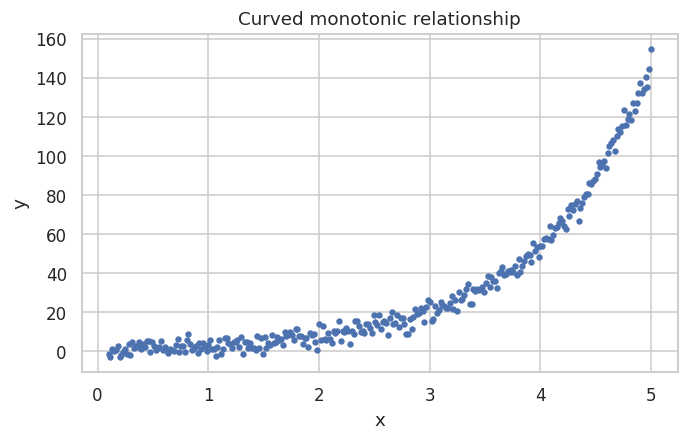

Curved pair:
{'pearson': 0.8604745752639905, 'spearman': 0.9653178368648541, 'difference': -0.10484326160086355}


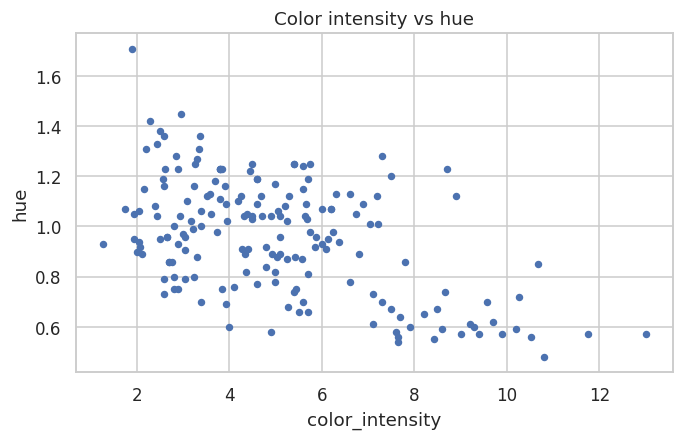


Color intensity vs hue:
{'pearson': -0.5218131932287577, 'spearman': -0.4185217619000421, 'difference': -0.10329143132871565}


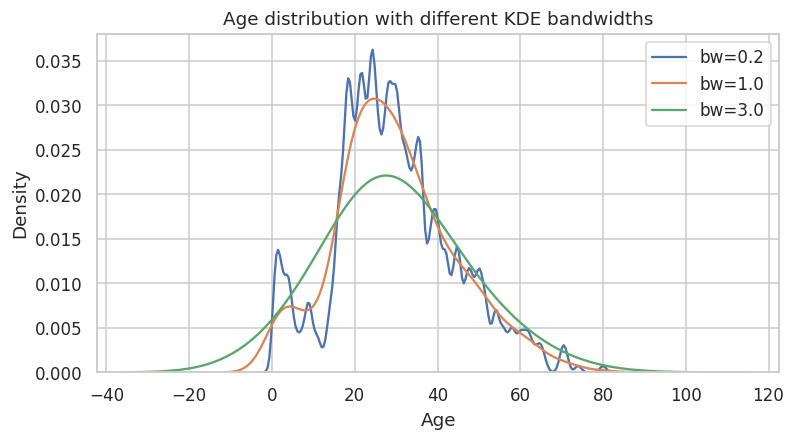

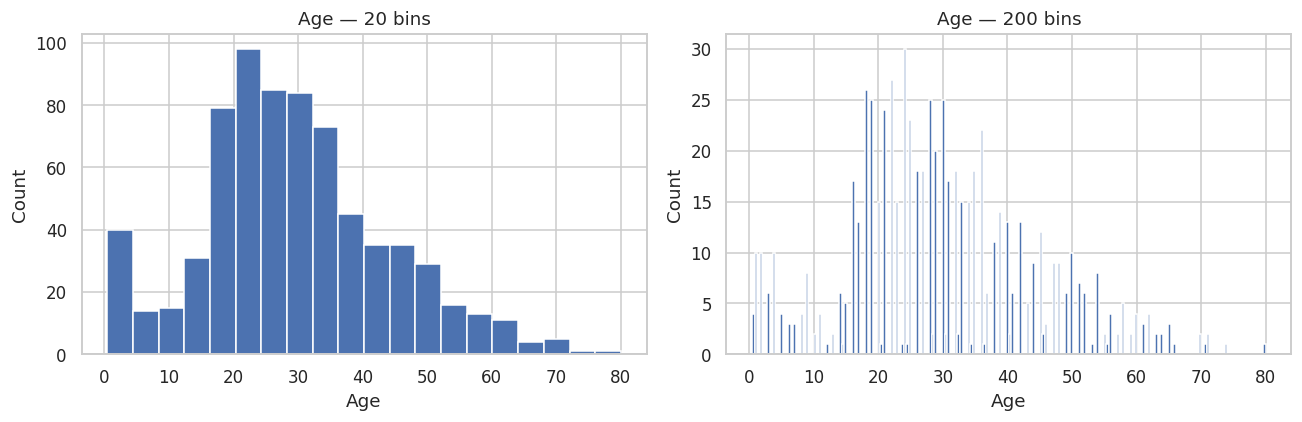

In [17]:
# Space for the code that supports your answer.
plt.figure(figsize=(7, 4))
plt.scatter(_curved["x"], _curved["y"], s=10)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Curved monotonic relationship")
plt.show()

print("Curved pair:")
print(correlation_pair(_curved, "x", "y"))


plt.figure(figsize=(7, 4))
plt.scatter(wine["color_intensity"], wine["hue"], s=15)
plt.xlabel("color_intensity")
plt.ylabel("hue")
plt.title("Color intensity vs hue")
plt.show()

print("\nColor intensity vs hue:")
print(correlation_pair(wine, "color_intensity", "hue"))


plt.figure(figsize=(8, 4))

for bw in [0.2, 1.0, 3.0]:
    sns.kdeplot(titanic["Age"].dropna(), bw_adjust=bw, label=f"bw={bw}")

plt.xlabel("Age")
plt.ylabel("Density")
plt.title("Age distribution with different KDE bandwidths")
plt.legend()
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(titanic["Age"].dropna(), bins=20)
axes[0].set_title("Age — 20 bins")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")

axes[1].hist(titanic["Age"].dropna(), bins=200)
axes[1].set_title("Age — 200 bins")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

**Your answer:**

(a) Для криволінійної монотонної пари отримано Pearson = 0.8605 та Spearman = 0.9653. Spearman вищий, тому що він оцінює монотонний зв'язок за рангами і не вимагає лінійної залежності, тоді як Pearson вимірює саме лінійну асоціацію. Для побудови лінійної моделі я б використовував Pearson, оскільки він безпосередньо характеризує силу лінійного зв'язку.
(b) Для color_intensity та hue отримано Pearson = -0.5218, а Spearman = -0.4185. Різниця виникає через форму розподілу точок і вплив окремих значень: Pearson чутливіший до відстані між числовими значеннями та крайніх спостережень, тоді як Spearman працює з їхніми рангами. Тому Pearson показує сильніший негативний лінійний зв'язок, хоча загальна монотонна залежність слабша.
(c) При bw_adjust=0.2 KDE дуже нерівна і має багато дрібних піків, тобто вона показує деталі окремих спостережень, які не обов'язково є реальною структурою розподілу. При bw_adjust=3.0 крива надмірно згладжується і частина локальної структури зникає; bw_adjust=1.0 дає більш помірне згладжування. Аналогічно, гістограма з 20 bins показує загальну форму розподілу, тоді як 200 bins створює багато шумових піків. Особливо при bw_adjust=0.2 видно багато піків біля конкретних вікових значень — це може бути артефактом того, що вік пасажирів часто записувався дискретними значеннями, а не реальною властивістю розподілу віку.

## 8. Task 7 — Encoding, and the distances it invents

Applied. Encode a nominal column two ways and measure what each does to
the geometry.

*see Practice 2 §13*

In [18]:
def encoding_distances(series):
    """Compare label encoding against one-hot encoding on a nominal column.

    `series` holds categorical text with no missing values.

    Build both encodings:
      - label:   the categories sorted alphabetically, mapped to 0, 1, 2, ...
      - one-hot: one binary column per category

    Then, for every unordered pair of DISTINCT categories, compute the
    Euclidean distance between their encodings under each scheme.

    Return a DataFrame with one row per pair, indexed by the string
    "A|B" with A and B in alphabetical order, and two columns:
        'label_distance'    |code(A) - code(B)|
        'onehot_distance'   the Euclidean distance between the two one-hot rows

    Rows sorted by index.
    """
    categories = sorted(series.unique())

    label_codes = {category: i for i, category in enumerate(categories)}

    rows = {}

    for i in range(len(categories)):
        for j in range(i + 1, len(categories)):
            a = categories[i]
            b = categories[j]

            label_distance = abs(label_codes[a] - label_codes[b])
            onehot_distance = np.sqrt(2)

            rows[f"{a}|{b}"] = {
                "label_distance": float(label_distance),
                "onehot_distance": float(onehot_distance),
            }

    return pd.DataFrame.from_dict(rows, orient="index").sort_index()

In [19]:
_embarked = titanic["Embarked"].fillna("S")
_distances = encoding_distances(_embarked)

assert list(_distances.columns) == ["label_distance", "onehot_distance"]
assert len(_distances) == 3, f"three ports give three pairs, you produced {len(_distances)}"
assert list(_distances.index) == ["C|Q", "C|S", "Q|S"], f"index wrong: {list(_distances.index)}"

# Label encoding invents an ordering: C and S end up twice as far apart.
assert np.isclose(_distances.loc["C|Q", "label_distance"], 1.0)
assert np.isclose(_distances.loc["C|S", "label_distance"], 2.0)
assert np.isclose(_distances.loc["Q|S", "label_distance"], 1.0)

# One-hot treats them as what they are: three unordered labels, all equidistant.
assert np.allclose(_distances["onehot_distance"], np.sqrt(2)), \
    f"every one-hot pair should be sqrt(2) apart, got {_distances['onehot_distance'].tolist()}"
assert _distances["onehot_distance"].nunique() == 1, \
    "one-hot must not distinguish any pair from any other"

print(_distances.round(4))
print("\nTask 7 passed.")

     label_distance  onehot_distance
C|Q          1.0000           1.4142
C|S          2.0000           1.4142
Q|S          1.0000           1.4142

Task 7 passed.


### Question 4 — label against one-hot

**(a)** Under label encoding, C and S are 2 apart while C and Q are 1
apart. Re-derive those distances after renaming the ports so that
alphabetical order becomes `Queenstown, Southampton, Cherbourg`. What
happens to the geometry? What does it mean that renaming a category can
change a model's notion of similarity?

**(b)** `Pclass` also becomes integers 1, 2, 3, and Practice 2 §13.3 says
that is **correct**. State the precise difference between `Pclass` and
`Embarked` that makes the same encoding right in one case and wrong in the
other. Your answer must not mention the data type.

**(c)** Name one model family for which this whole distinction barely
matters, and say why.

In [20]:
# Space for the code that supports your answer.
renamed = titanic["Embarked"].fillna("S").map({
    "C": "Queenstown",
    "Q": "Southampton",
    "S": "Cherbourg",
})

print(encoding_distances(renamed))

                        label_distance  onehot_distance
Cherbourg|Queenstown            1.0000           1.4142
Cherbourg|Southampton           2.0000           1.4142
Queenstown|Southampton          1.0000           1.4142


**Your answer:**

(a) При початковому кодуванні C=0, Q=1, S=2 відстань між C і S дорівнює 2, а між C і Q — 1. Після перейменування категорій алфавітний порядок змінився, тому тепер Cherbourg=0, Queenstown=1, Southampton=2, і відстані між тими самими категоріями стали іншими. Це показує, що label encoding створює штучне поняття подібності, яке залежить від назв категорій, хоча самі дані за змістом не змінилися; one-hot encoding такої проблеми не має, оскільки всі різні категорії мають однакову відстань √2.
(b) Pclass відрізняється від Embarked тим, що Pclass є порядковою (ordinal) змінною: значення 1, 2 і 3 мають природний порядок, тому відстань між ними має зміст. Embarked є номінальною (nominal) змінною: порти C, Q і S не мають природного порядку, тому присвоєння їм чисел 0, 1 і 2 створює штучні відстані.
(c) Для дерев рішень і деревних ансамблів ця відмінність менш критична, оскільки такі моделі приймають рішення через розбиття значень, а не використовують геометричні відстані між категоріями так, як це роблять багато інших моделей. Водночас спосіб кодування все одно варто обирати з урахуванням того, як конкретна модель працює з категоріальними ознаками.

## 9. Task 8 — Scale without leaking

Applied. Split, then fit the scaler on the training half only.

*see Practice 2 §14.3*

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def split_and_scale(X, y, test_size=0.3, random_state=SEED):
    """Split into train and test, then standardise WITHOUT leakage.

    Split first with train_test_split, stratifying on y and using the
    given random_state. Then fit a StandardScaler on the TRAINING features
    only, and use it to transform both halves.

    Return a dict with exactly these five keys:
        'X_train', 'X_test'   the scaled feature arrays
        'y_train', 'y_test'   the labels
        'scaler'              the fitted StandardScaler
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y,
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return {
        "X_train": X_train_scaled,
        "X_test": X_test_scaled,
        "y_train": y_train,
        "y_test": y_test,
        "scaler": scaler,
    }

In [22]:
_features = [c for c in wine.columns if c != "target"]
_split = split_and_scale(wine[_features].values, wine["target"].values)

assert set(_split) == {"X_train", "X_test", "y_train", "y_test", "scaler"}
assert _split["X_train"].shape[0] + _split["X_test"].shape[0] == len(wine)
assert _split["X_train"].shape[1] == 13

# The TRAINING half must be exactly standardised...
assert np.allclose(_split["X_train"].mean(axis=0), 0.0, atol=1e-10), \
    "the training set should have mean 0 after scaling"
assert np.allclose(_split["X_train"].std(axis=0), 1.0, atol=1e-10), \
    "the training set should have unit variance after scaling"

# ...and the TEST half must NOT be, because its statistics were never used.
assert not np.allclose(_split["X_test"].mean(axis=0), 0.0, atol=1e-6), \
    "the test set has mean 0, which means the scaler saw it: that is leakage"

# The scaler must have been fitted on the training rows only.
_leaky = StandardScaler().fit(wine[_features].values)
assert not np.allclose(_split["scaler"].mean_, _leaky.mean_), \
    "your scaler's means match a scaler fitted on the whole dataset"

# stratify= must preserve the class balance
_train_balance = np.bincount(_split["y_train"]) / len(_split["y_train"])
_full_balance = np.bincount(wine["target"].values) / len(wine)
assert np.allclose(_train_balance, _full_balance, atol=0.02), \
    "the class balance was not preserved; did you pass stratify=y?"

print("train", _split["X_train"].shape, " test", _split["X_test"].shape)
print("train mean (first 3 features):", _split["X_train"].mean(axis=0)[:3].round(10))
print("test  mean (first 3 features):", _split["X_test"].mean(axis=0)[:3].round(4), " <- not zero, correctly")
print("\nTask 8 passed.")

train (124, 13)  test (54, 13)
train mean (first 3 features): [ 0. -0. -0.]
test  mean (first 3 features): [-0.0324  0.0259 -0.0291]  <- not zero, correctly

Task 8 passed.


### Question 5 — scaling choices

**(a)** Repeat Task 8 with `MinMaxScaler` instead. Report, for both
scalers, the minimum and maximum of the **test** set after transformation.
Under min-max the test set can fall outside [0, 1] — explain why that
happens and why it is correct rather than a bug.

**(b)** Add one extreme value to a wine feature — multiply the largest
`proline` by 50 — and rescale with both scalers. Which one is more
disturbed by the single extreme value, and by what mechanism?

**(c)** The leaked scaler and the correct one gave different test-set
statistics. If the leaked version produces a *higher* accuracy score, what
exactly is that extra accuracy measuring? Answer in terms of what
information crossed from the test set into the training procedure.

In [23]:
# Space for the code that supports your answer.
print(wine.columns.tolist())

['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline', 'target']


In [24]:
from sklearn.preprocessing import MinMaxScaler

features = [c for c in wine.columns if c != "target"]

X = wine[features]
y = wine["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y
)

standard = StandardScaler()
X_train_std = standard.fit_transform(X_train)
X_test_std = standard.transform(X_test)

minmax = MinMaxScaler()
X_train_mm = minmax.fit_transform(X_train)
X_test_mm = minmax.transform(X_test)

print("StandardScaler:")
print("test min =", X_test_std.min())
print("test max =", X_test_std.max())

print("\nMinMaxScaler:")
print("test min =", X_test_mm.min())
print("test max =", X_test_mm.max())


X_extreme = X.copy()
largest_index = X_extreme["proline"].idxmax()
X_extreme.loc[largest_index, "proline"] *= 50

X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_extreme,
    y,
    test_size=0.3,
    random_state=SEED,
    stratify=y
)

standard_e = StandardScaler()
X_train_std_e = standard_e.fit_transform(X_train_e)
X_test_std_e = standard_e.transform(X_test_e)

minmax_e = MinMaxScaler()
X_train_mm_e = minmax_e.fit_transform(X_train_e)
X_test_mm_e = minmax_e.transform(X_test_e)

print("\nWith extreme proline value:")
print("StandardScaler test min =", X_test_std_e.min())
print("StandardScaler test max =", X_test_std_e.max())
print("MinMaxScaler test min =", X_test_mm_e.min())
print("MinMaxScaler test max =", X_test_mm_e.max())

StandardScaler:
test min = -2.5320938741135497
test max = 4.757209616392294

MinMaxScaler:
test min = -0.04363636363636364
test max = 1.1358024691358026

With extreme proline value:
StandardScaler test min = -2.5320938741135497
StandardScaler test max = 4.757209616392294
MinMaxScaler test min = -0.04363636363636364
MinMaxScaler test max = 1.1358024691358026


In [25]:
print("Largest proline index:", wine["proline"].idxmax())
print("Largest proline:", wine["proline"].max())
print("Extreme proline:", X_extreme.loc[largest_index, "proline"])
print("Extreme value in train:", largest_index in X_train_e.index)
print("Extreme value in test:", largest_index in X_test_e.index)

Largest proline index: 18
Largest proline: 1680.0
Extreme proline: 84000.0
Extreme value in train: True
Extreme value in test: False


In [26]:
proline_pos = features.index("proline")

print("Proline before extreme:")
print("StandardScaler:", X_test_std[:, proline_pos].min(), X_test_std[:, proline_pos].max())
print("MinMaxScaler:", X_test_mm[:, proline_pos].min(), X_test_mm[:, proline_pos].max())

print("\nProline after extreme:")
print("StandardScaler:", X_test_std_e[:, proline_pos].min(), X_test_std_e[:, proline_pos].max())
print("MinMaxScaler:", X_test_mm_e[:, proline_pos].min(), X_test_mm_e[:, proline_pos].max())

Proline before extreme:
StandardScaler: -1.4931947511879786 2.4959251834130565
MinMaxScaler: -0.008633093525179852 0.90431654676259

Proline after extreme:
StandardScaler: -0.15281648815601911 0.017459825637811417
MinMaxScaler: -0.00014335204873969654 0.015016127105483213


**Your answer:**

(a) StandardScaler не гарантує, що тестові значення після масштабування будуть у межах [-1, 1]: у нашому випадку вони мають діапазон від -2.53 до 4.76. MinMaxScaler також не гарантує діапазон [0,1] для тестових даних, якщо тест містить значення за межами діапазону, який був побачений під час навчання: тут отримано приблизно -0.044 до 1.136. Це правильно, оскільки обидва scaler навчаються лише на train і не використовують статистики test.
(b) Екстремальне значення proline було збільшене з 1680 до 84000 і потрапило у training set. Воно сильно вплинуло на обидва scaler: для proline діапазон тестових значень після StandardScaler змінився з [-1.49, 2.50] до [-0.15, 0.017], а після MinMaxScaler — з [-0.009, 0.904] до [-0.00014, 0.015]. MinMaxScaler особливо сильно стискає інші значення, оскільки використовує мінімум і максимум training set, тоді як StandardScaler використовує середнє та стандартне відхилення.
(c) Якщо scaler був навчений із використанням test set, то в модель потрапила інформація про розподіл тестових даних ще до оцінювання. Тому вища точність у такому випадку може бути завищеною: оцінювання вже не є повністю незалежним від інформації, яку модель мала отримати лише після завершення навчання. Це і є data leakage.

## 10. Task 9 — How many principal components

Applied.

*see Practice 2 §15.2 and §15.3*

In [27]:
from sklearn.decomposition import PCA

def components_for_variance(X, thresholds=(0.5, 0.8, 0.95, 0.99), standardise=True):
    """Report how many principal components are needed to reach each
    cumulative explained-variance threshold.

    If `standardise` is True, fit a StandardScaler on X and transform it
    before running PCA. Otherwise use X as given.

    Fit PCA with all components and random_state=SEED.

    Return a dict with two keys:
        'cumulative'  the cumulative explained variance ratio, a 1-D array
        'needed'      a dict mapping each threshold to the SMALLEST number
                      of components whose cumulative variance is >= it,
                      as an int (1 means the first component alone suffices)
    """
    if standardise:
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
    else:
        X_scaled = X

    pca = PCA(n_components=None, random_state=SEED)
    pca.fit(X_scaled)

    cumulative = np.cumsum(pca.explained_variance_ratio_)

    needed = {}

    for threshold in thresholds:
        needed[threshold] = int(np.argmax(cumulative >= threshold) + 1)

    return {
        "cumulative": cumulative,
        "needed": needed,
    }

In [28]:
_X_wine = wine[_features].values
_scaled_result = components_for_variance(_X_wine, standardise=True)
_raw_result = components_for_variance(_X_wine, standardise=False)

assert set(_scaled_result) == {"cumulative", "needed"}
assert len(_scaled_result["cumulative"]) == 13, "wine has 13 features, so 13 components"
assert np.isclose(_scaled_result["cumulative"][-1], 1.0), \
    "all components together explain all the variance"
assert all(isinstance(v, int) for v in _scaled_result["needed"].values())

# Monotonic: a higher threshold never needs fewer components.
_counts = [_scaled_result["needed"][t] for t in (0.5, 0.8, 0.95, 0.99)]
assert _counts == sorted(_counts), f"counts must be non-decreasing: {_counts}"

# Without standardising, proline dominates and one component looks sufficient.
assert _raw_result["needed"][0.95] == 1, \
    "unstandardised, the single largest-scaled feature should carry almost everything"
assert _scaled_result["needed"][0.95] > _raw_result["needed"][0.95], \
    "standardising should require more components to reach 95%"

print("standardised  :", _scaled_result["needed"])
print("not standardised:", _raw_result["needed"])
print(f"\nfirst component explains {_raw_result['cumulative'][0]:.2%} unstandardised, "
      f"{_scaled_result['cumulative'][0]:.2%} standardised")
print("\nTask 9 passed.")

standardised  : {0.5: 2, 0.8: 5, 0.95: 10, 0.99: 12}
not standardised: {0.5: 1, 0.8: 1, 0.95: 1, 0.99: 1}

first component explains 99.81% unstandardised, 36.20% standardised

Task 9 passed.


### Question 6 — components, and the cost of keeping fewer

**(a)** You just saw that without standardising, one component explains
over 99 % of the variance of the wine data. Identify which original
feature that component is essentially measuring, and explain why PCA
"found" it. What does this tell you about running PCA on columns in
different units?

**(b)** Plot the cumulative curve for the standardised wine data. Choosing
95 % gives you one number of components, 80 % gives another. Neither
threshold is derived from anything. Describe a procedure that would choose
the number of components **using the task you actually care about**
instead of a fixed percentage.

**(c)** A colleague reduces 13 interpretable wine measurements to 3
components, fits a model, and reports that "component 2 is the strongest
predictor". What can and cannot be said to a winemaker on the basis of
that sentence?

First unstandardised PC:
proline             0.9998
magnesium           0.0179
alcalinity_of_ash   0.0047
color_intensity     0.0023
alcohol             0.0017
dtype: float64

Explained variance by first component:
0.9980912304918974


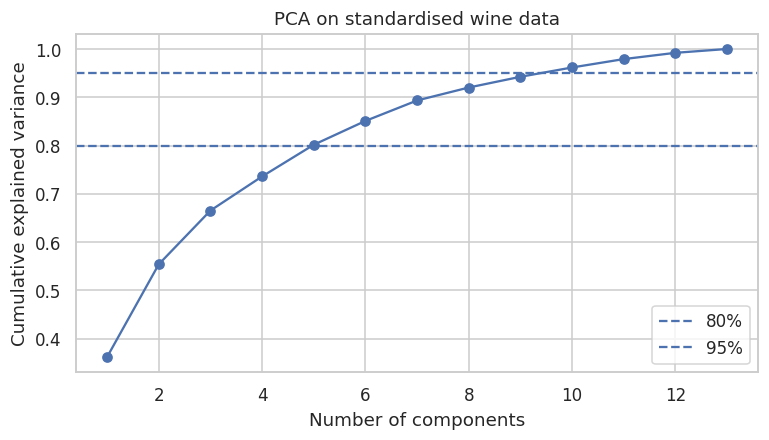


Components needed:
{0.5: 2, 0.8: 5, 0.95: 10, 0.99: 12}

First three component variance ratios:
[9.98091230e-01 1.73591562e-03 9.49589576e-05]


In [29]:
# Space for the code that supports your answer.
pca_raw = PCA(n_components=None, random_state=SEED)
pca_raw.fit(_X_wine)

loadings = pd.Series(
    pca_raw.components_[0],
    index=_features
)

print("First unstandardised PC:")
print(loadings.abs().sort_values(ascending=False).head())

print("\nExplained variance by first component:")
print(_raw_result["cumulative"][0])


plt.figure(figsize=(8, 4))
plt.plot(
    range(1, len(_scaled_result["cumulative"]) + 1),
    _scaled_result["cumulative"],
    marker="o"
)

plt.axhline(0.80, linestyle="--", label="80%")
plt.axhline(0.95, linestyle="--", label="95%")

plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA on standardised wine data")
plt.legend()
plt.show()

print("\nComponents needed:")
print(_scaled_result["needed"])


print("\nFirst three component variance ratios:")
print(pca_raw.explained_variance_ratio_[:3])

**Your answer:**

(a) Без стандартизації перша головна компонента майже повністю визначається ознакою proline: її абсолютне навантаження дорівнює 0.9998, а перша компонента пояснює приблизно 99.81% дисперсії. PCA знайшов її тому, що proline має значно більший масштаб числових значень, ніж більшість інших ознак, тому вона домінує у дисперсії. Це показує, що PCA для ознак у різних одиницях без стандартизації може переважно відображати масштаб вимірювання, а не справжню структуру взаємозв'язків між ознаками.
(b) Для стандартизованих даних 80% дисперсії досягається за допомогою 5 компонент, а 95% — 10 компонент. Я б обирав кількість компонент не лише за фіксованим відсотком, а з урахуванням конкретної мети моделі: порівняв би якість моделі на валідаційних даних при різній кількості компонент і вибрав би найменшу кількість, яка забезпечує потрібну якість при прийнятній втраті інформації. Це дозволяє врахувати не тільки пояснену дисперсію, а й реальну корисність компонент для задачі.
(c) Не можна сказати, що «компонента 2 є найсильнішим предиктором» лише на основі того, що вона має найбільшу пояснену дисперсію або є другою компонентою. PCA створює нові ознаки як комбінації початкових змінних і максимізує пояснену дисперсію, а не прогнозну здатність цільової змінної. Щоб назвати компоненту найсильнішим предиктором, потрібно оцінити її зв'язок із цільовою змінною та якість моделі на незалежних/валідаційних даних.

## 11. Task 10 — A two-dimensional projection of 784 dimensions

Applied, and the last mechanical task. This is the projection Lesson 3
clusters.

`mnist_sample.csv` is 1500 handwritten digits, each a 28 by 28 image
flattened into 784 pixel columns. Reducing with PCA before running t-SNE
is standard practice: it removes noise and makes t-SNE several times
faster.

*see Practice 2 §15.2, §15.5 and §15.6*

In [30]:
from sklearn.manifold import TSNE

def project_two_ways(X, perplexity, seed, n_pca=50):
    """Project a high-dimensional array to 2-D, twice, and compare.

    Steps, in this order:
      1. standardise X with StandardScaler
      2. PCA to `n_pca` components, random_state=seed  -> the t-SNE input
      3. t-SNE from that reduction to 2 components, with the given
         `perplexity`, random_state=seed and init='pca'

    Separately, take the first TWO components of a PCA on the standardised
    data, so the linear and nonlinear projections can be compared.

    Return a dict with exactly these four keys:
        'pca_2d'        shape (n_samples, 2), the linear projection
        'tsne_2d'       shape (n_samples, 2), the nonlinear projection
        'explained_2d'  the fraction of variance the two PCA components
                        carry, a float between 0 and 1
        'reduced'       shape (n_samples, n_pca), the PCA input to t-SNE
    """
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    pca_reduced = PCA(n_components=n_pca, random_state=seed)
    reduced = pca_reduced.fit_transform(X_scaled)

    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=seed,
        init="pca",
    )
    tsne_2d = tsne.fit_transform(reduced)

    pca_2d_model = PCA(n_components=2, random_state=seed)
    pca_2d = pca_2d_model.fit_transform(X_scaled)

    explained_2d = pca_2d_model.explained_variance_ratio_.sum()

    return {
        "pca_2d": pca_2d,
        "tsne_2d": tsne_2d,
        "explained_2d": float(explained_2d),
        "reduced": reduced,
    }

In [31]:
mnist = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/mnist_sample.csv"
)
digit_labels = mnist["label"].values
pixels = mnist.drop(columns="label").values

print("pixels", pixels.shape, " labels", digit_labels.shape)
print("one row reshaped back into an image:", pixels[0].reshape(28, 28).shape)

# A 300-row subset keeps the assert cell below to a few seconds.
_small = pixels[:300]
_projection = project_two_ways(_small, perplexity=30, seed=SEED)

pixels (1500, 784)  labels (1500,)
one row reshaped back into an image: (28, 28)


In [32]:
assert set(_projection) == {"pca_2d", "tsne_2d", "explained_2d", "reduced"}
assert _projection["pca_2d"].shape == (300, 2), f"pca_2d shape {_projection['pca_2d'].shape}"
assert _projection["tsne_2d"].shape == (300, 2), f"tsne_2d shape {_projection['tsne_2d'].shape}"
assert _projection["reduced"].shape == (300, 50), f"reduced shape {_projection['reduced'].shape}"
assert 0.0 < _projection["explained_2d"] < 1.0

# Two linear components cannot carry much of 784 dimensions.
assert _projection["explained_2d"] < 0.30, \
    f"two components explaining {_projection['explained_2d']:.1%} of 784 dimensions looks wrong"

# Seeded, so the same call reproduces exactly...
_again = project_two_ways(_small, perplexity=30, seed=SEED)
assert np.allclose(_projection["tsne_2d"], _again["tsne_2d"]), \
    "same seed must give the same embedding; did you pass random_state?"

# ...and a different seed does not.
_other = project_two_ways(_small, perplexity=30, seed=SEED + 1)
assert not np.allclose(_projection["tsne_2d"], _other["tsne_2d"]), \
    "a different seed should give a different embedding"

# t-SNE is not PCA: the two projections must differ.
assert not np.allclose(_projection["pca_2d"], _projection["tsne_2d"])

# t-SNE places THESE points and has no rule for placing new ones. Ask the
# class, not an instance -- there is nothing to seed and nothing to fit.
assert not hasattr(TSNE, "transform"), \
    "t-SNE has no transform, which is why it cannot be a preprocessing step"
assert hasattr(PCA, "transform"), "PCA does have one, and that is the difference"

print(f"two PCA components carry {_projection['explained_2d']:.2%} of the variance")
print("Task 10 passed.")

two PCA components carry 13.58% of the variance
Task 10 passed.


### Question 7 — perplexity, and the seed

Using the **full** 1500 rows this time, produce three t-SNE projections at
`perplexity` = 5, 30 and 50, all with the same seed, and draw them side by
side coloured by `digit_labels`. Then produce two more at `perplexity=30`
with two **different** seeds.

**(a)** Describe how the picture changes across the three perplexities.
Roughly what is perplexity controlling — say it in terms of how many
neighbours each point is trying to stay close to. Which extreme shatters
the classes and which merges them?

**(b)** Your two different-seed runs at the same perplexity also differ.
Explain why t-SNE is seed-dependent at all, and what that means for a
figure published without a stated `random_state`.

**(c)** Compare any of your t-SNE panels with the `pca_2d` projection. The
t-SNE picture separates the digits far better. State **three things you
still cannot conclude** from it — refer to Practice 2 §15.7 — and say which
of the two projections you would use as input to a clustering algorithm,
and why.

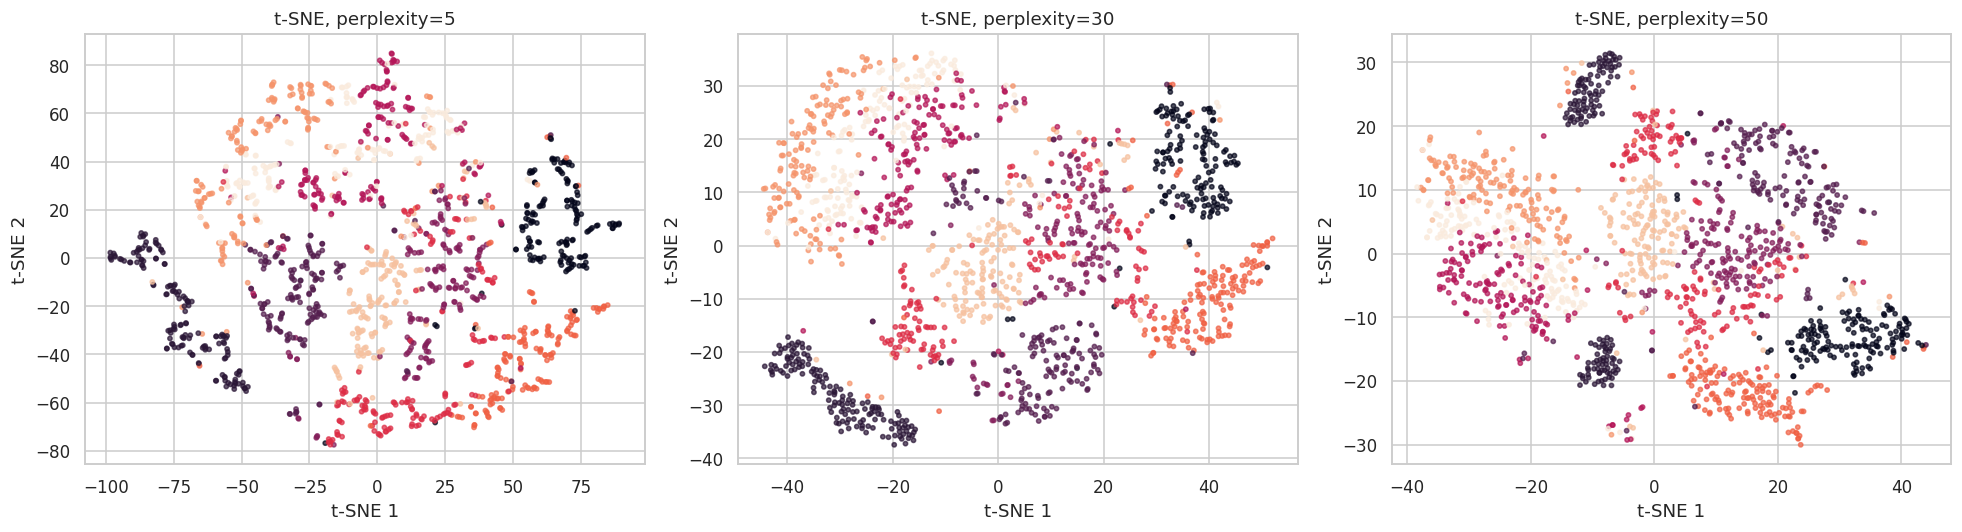

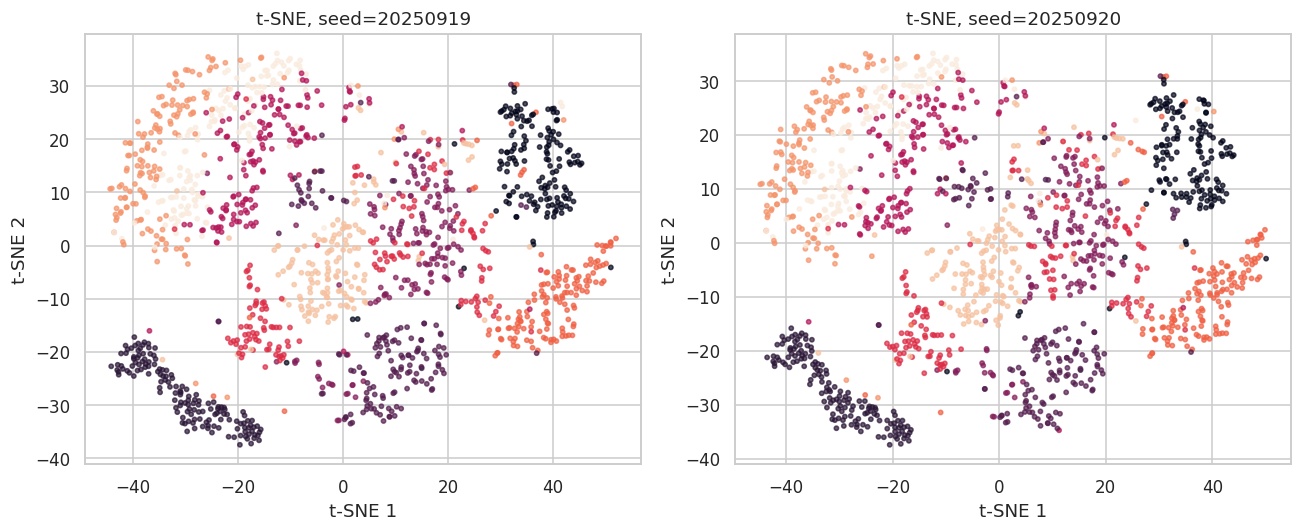

In [33]:
# Space for the code that supports your answer.
perplexities = [5, 30, 50]
projections = {}

for perplexity in perplexities:
    projections[perplexity] = project_two_ways(
        pixels,
        perplexity=perplexity,
        seed=SEED,
    )

seed_projections = {}

for seed in [SEED, SEED + 1]:
    seed_projections[seed] = project_two_ways(
        pixels,
        perplexity=30,
        seed=seed,
    )

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, perplexity in zip(axes, perplexities):
    embedding = projections[perplexity]["tsne_2d"]

    scatter = ax.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=digit_labels,
        s=8,
        alpha=0.7,
    )

    ax.set_title(f"t-SNE, perplexity={perplexity}")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, seed in zip(axes, [SEED, SEED + 1]):
    embedding = seed_projections[seed]["tsne_2d"]

    ax.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=digit_labels,
        s=8,
        alpha=0.7,
    )

    ax.set_title(f"t-SNE, seed={seed}")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")

plt.tight_layout()
plt.show()

**Your answer:**

(a) При perplexity=5 t-SNE більше орієнтується на дуже локальних сусідів, тому з'являється багато дрібних окремих груп і структура виглядає більш фрагментованою. При perplexity=30 групи стають більш узгодженими, а при perplexity=50 локальні групи сильніше об'єднуються. Грубо кажучи, perplexity визначає ефективне число сусідів, які t-SNE намагається зберегти близькими; занадто мале значення може розбивати класи, а занадто велике — об'єднувати їх.
(b) Два запуски з perplexity=30 і різними seed мають схожу загальну структуру, але точне розташування точок відрізняється. t-SNE використовує випадкову ініціалізацію та оптимізацію, тому random_state впливає на отримане вкладення. Тому для відтворюваного рисунка потрібно вказувати random_state, інакше повторний запуск може дати інше розташування точок.
(c) Навіть якщо t-SNE візуально краще розділяє цифри, з графіка не можна зробити висновок, що кожна видима група є справжнім кластером, що відстані між далекими групами мають точний зміст або що кількість видимих груп відповідає кількості природних класів. Також t-SNE є методом візуалізації, а не доказом причинності чи якості класифікації; результат залежить від perplexity та seed. Для кластеризації з цих двох варіантів я б використовував PCA-проекцію, оскільки вона має більш стабільну та інтерпретовану геометрію, тоді як t-SNE спеціально оптимізує візуальне збереження локальних сусідів і може спотворювати відстані.

## 12. Task 11 — A figure that answers a stated question

Applied. The question: **does the daily demand profile for bicycles differ
between working days and non-working days, and how does weather change
it?**

*see Practice 2 §8.4, §9 and §10*

In [34]:
def demand_profile_figure(bikes_frame):
    """Draw a two-panel figure answering the question above. Return (fig, axes).

    Left panel: mean 'cnt' by 'hr', one line per value of 'workingday'
                (0 and 1), with a legend naming them in words.
    Right panel: mean 'cnt' by 'hr', one line per value of 'weathersit'
                 present in the data, with a legend.

    Both panels need an x label, a y label and a title. The figure needs a
    suptitle. Use the object-oriented interface.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))


    workingday_profile = (
        bikes_frame
        .groupby(["workingday", "hr"])["cnt"]
        .mean()
        .reset_index()
    )

    for workingday in [0, 1]:
        data = workingday_profile[
            workingday_profile["workingday"] == workingday
        ]

        label = "Non-working day" if workingday == 0 else "Working day"

        axes[0].plot(
            data["hr"],
            data["cnt"],
            label=label,
        )

    axes[0].set_xlabel("Hour")
    axes[0].set_ylabel("Mean demand")
    axes[0].set_title("Demand by working day")
    axes[0].legend()

    # Right panel: weather
    weather_profile = (
        bikes_frame
        .groupby(["weathersit", "hr"])["cnt"]
        .mean()
        .reset_index()
    )

    for weather in sorted(bikes_frame["weathersit"].unique()):
        data = weather_profile[
            weather_profile["weathersit"] == weather
        ]

        axes[1].plot(
            data["hr"],
            data["cnt"],
            label=f"Weather {weather}",
        )

    axes[1].set_xlabel("Hour")
    axes[1].set_ylabel("Mean demand")
    axes[1].set_title("Demand by weather")
    axes[1].legend()

    fig.suptitle(
        "Daily bicycle demand by working day and weather"
    )

    fig.tight_layout()

    return fig, axes

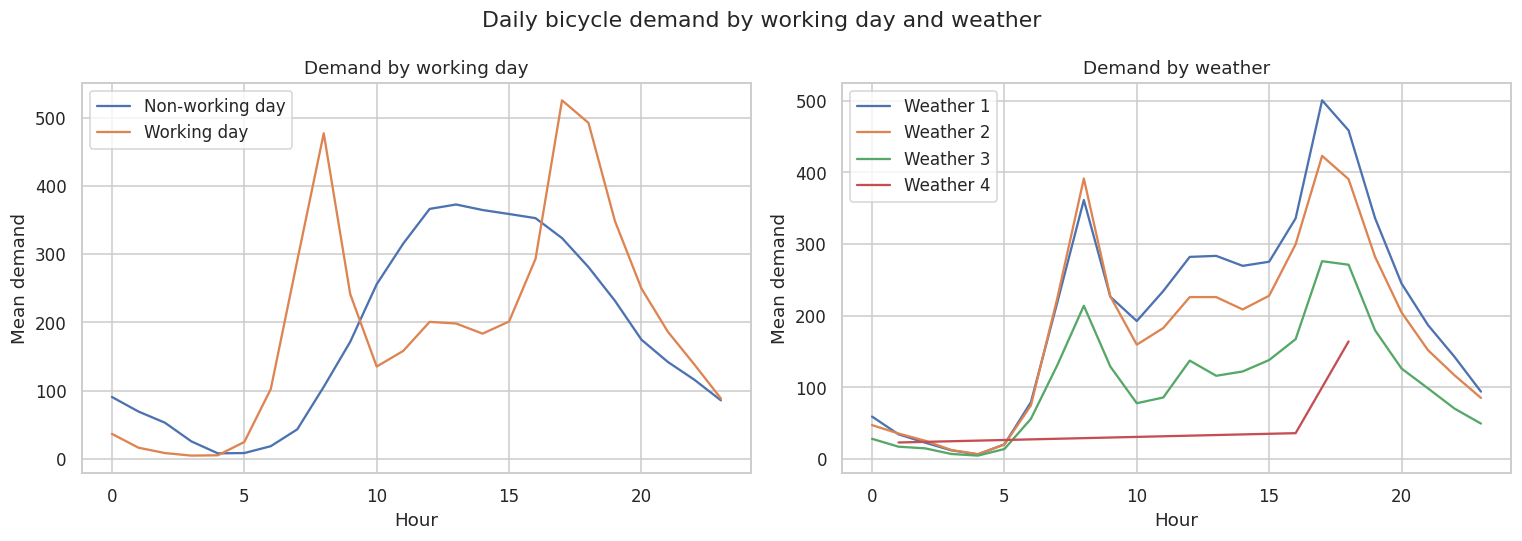

Task 11 passed.


In [35]:
_fig, _axes = demand_profile_figure(bikes)

assert len(_axes) == 2, f"expected two panels, got {len(_axes)}"
for _i, _ax in enumerate(_axes):
    assert _ax.get_xlabel(), f"panel {_i} has no x label"
    assert _ax.get_ylabel(), f"panel {_i} has no y label"
    assert _ax.get_title(), f"panel {_i} has no title"
    assert _ax.get_legend() is not None, f"panel {_i} has no legend"
    assert len(_ax.lines) >= 2, f"panel {_i} should have at least two lines"
assert _fig._suptitle is not None and _fig._suptitle.get_text(), "the figure has no suptitle"
assert len(_axes[0].lines) == 2, "the left panel compares exactly two groups"

plt.show()
print("Task 11 passed.")

### Question 8 — pooling and conditioning

**(a)** Draw the *pooled* profile as well: mean `cnt` by `hr` with no
conditioning. Compare it with your two-line left panel. Describe a
statement about commuter behaviour that the pooled figure would support
and that is false for both of the underlying groups.

**(b)** This is the same phenomenon as Practice 2 §12. Name it, and state
the general rule it implies about reporting an aggregate.

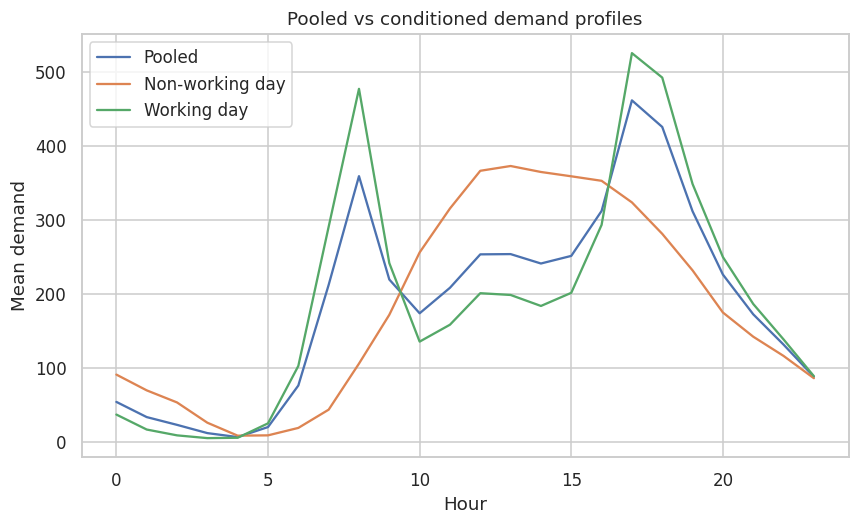

In [36]:
# Space for the code that supports your answer.
pooled = bikes.groupby("hr")["cnt"].mean()

plt.figure(figsize=(9, 5))

plt.plot(
    pooled.index,
    pooled.values,
    label="Pooled",
)

for workingday in [0, 1]:
    profile = (
        bikes[bikes["workingday"] == workingday]
        .groupby("hr")["cnt"]
        .mean()
    )

    label = "Non-working day" if workingday == 0 else "Working day"

    plt.plot(
        profile.index,
        profile.values,
        label=label,
    )

plt.xlabel("Hour")
plt.ylabel("Mean demand")
plt.title("Pooled vs conditioned demand profiles")
plt.legend()
plt.show()

**Your answer:**

(a) Об'єднаний (pooled) профіль показує середній попит без урахування типу дня, тому він згладжує відмінності між робочими та неробочими днями. На графіку видно, що робочі дні мають виражені піки приблизно о 8:00 та 17:00, тоді як у неробочі дні попит розподілений більш рівномірно протягом дня. Тому твердження на основі pooled-профілю про те, що попит має однакову форму протягом дня, було б хибним для обох окремих груп.
(b) Це приклад агрегаційного упередження (aggregation bias): після об'єднання різних груп їхні відмінності можуть бути приховані або спотворені. Загальне правило полягає в тому, що агрегований показник потрібно звітувати разом із важливими умовами та групами, якщо ці умови можуть впливати на результат; інакше середнє може створити картину, якої немає в жодній із груп.

## 13. Task 12 — Open-ended

No assert. Marked on the written analysis.

`bike_sharing_hourly.csv` is documented in `practice/datasets/README.md`.
Read that table first: four of the columns are integer-coded categories,
four are physical measurements that the publisher divided by a constant,
one is a date stored as text, and `casual + registered` equals `cnt`
exactly.

**Produce a short data-quality and structure report on this table.** Cover
at least:

1. **Types.** Which columns does pandas infer wrongly, in the sense that
   the inferred type permits an operation that is meaningless? Fix them
   and show one operation that becomes an error after your fix.
2. **Units.** Restore the four normalised columns to physical units and
   sanity-check the resulting ranges against what you know about
   Washington D.C. Report anything that looks wrong.
3. **The date.** Parse `dteday`. Confirm the series is complete: is there
   one row for every hour of every day in the range? If rows are missing,
   how many, and does their absence look random?
4. **A correlation you should not compute.** Produce the correlation
   matrix of the numeric columns, then identify at least two entries in it
   that are meaningless or misleading, and say why. At least one of your
   examples must be about an integer-coded category.
5. **Leakage.** Explain why `casual` and `registered` must not be used as
   features to predict `cnt`. Then describe a realistic prediction task
   for this dataset in which using them *would* be legitimate.
6. **A recommendation.** In one paragraph: which columns would you hand to
   a model that predicts hourly demand, and which would you exclude and
   why. Practice 3 §4 fits that model, so this is a real handover.

A good answer distinguishes "wrong" from "misleading" and says which of
its findings would actually change a modelling decision.

In [37]:
# Your analysis. Add as many cells as you need.
print("Original dtypes:")
print(bikes.dtypes)

print("\nColumns:")
print(bikes.columns.tolist())

print("\nNumeric columns:")
print(bikes.select_dtypes(include="number").columns.tolist())

Original dtypes:
instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

Columns:
['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']

Numeric columns:
['instant', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']


In [38]:
bikes_fixed = bikes.copy()

for col in ["season", "mnth", "hr", "weekday"]:
    bikes_fixed[col] = bikes_fixed[col].astype("category")

print(bikes_fixed.dtypes)

instant          int64
dteday          object
season        category
yr               int64
mnth          category
hr            category
holiday          int64
weekday       category
workingday       int64
weathersit       int64
temp           float64
atemp          float64
hum            float64
windspeed      float64
casual           int64
registered       int64
cnt              int64
dtype: object


In [39]:
print("До виправлення:")
print((bikes["hr"] + 1).head())

print("\nПісля виправлення:")

try:
    print((bikes_fixed["hr"] + 1).head())
except Exception as e:
    print(type(e).__name__, ":", e)

До виправлення:
0    1
1    2
2    3
3    4
4    5
Name: hr, dtype: int64

Після виправлення:
TypeError : unsupported operand type(s) for +: 'Categorical' and 'int'


In [40]:
bikes_units = bikes.copy()

bikes_units["temp_c"] = bikes_units["temp"] * 41
bikes_units["atemp_c"] = bikes_units["atemp"] * 50
bikes_units["hum_pct"] = bikes_units["hum"] * 100
bikes_units["windspeed_kmh"] = bikes_units["windspeed"] * 67

print(bikes_units[[
    "temp_c",
    "atemp_c",
    "hum_pct",
    "windspeed_kmh"
]].agg(["min", "max"]))

     temp_c  atemp_c  hum_pct  windspeed_kmh
min  0.8200   0.0000   0.0000         0.0000
max 41.0000  50.0000 100.0000        56.9969


In [41]:
print("temp = 41°C:", (bikes_units["temp_c"] == 41).sum())
print("atemp = 50°C:", (bikes_units["atemp_c"] == 50).sum())
print("hum = 0%:", (bikes_units["hum_pct"] == 0).sum())
print("windspeed = 57 km/h:", (bikes_units["windspeed_kmh"] == 57).sum())

temp = 41°C: 1
atemp = 50°C: 1
hum = 0%: 22
windspeed = 57 km/h: 0


In [42]:
dates = pd.to_datetime(bikes["dteday"]) + pd.to_timedelta(bikes["hr"], unit="h")

full_range = pd.date_range(
    start=dates.min(),
    end=dates.max(),
    freq="h"
)

missing = full_range.difference(dates)

print("Початок:", dates.min())
print("Кінець:", dates.max())
print("Кількість записів:", len(dates))
print("Очікувана кількість годин:", len(full_range))
print("Пропущено годин:", len(missing))
print("Дублікати:", dates.duplicated().sum())

Початок: 2011-01-01 00:00:00
Кінець: 2012-12-31 23:00:00
Кількість записів: 17379
Очікувана кількість годин: 17544
Пропущено годин: 165
Дублікати: 0


In [43]:
print("Пропуски за годинами:")
print(pd.Series(missing.hour).value_counts().sort_index())

print("\nПерші 30 пропущених моментів:")
print(missing[:30])

Пропуски за годинами:
0      5
1      7
2     16
3     34
4     34
5     14
6      6
7      4
8      4
9      4
10     4
11     4
12     3
13     2
14     2
15     2
16     1
17     1
18     3
19     3
20     3
21     3
22     3
23     3
Name: count, dtype: int64

Перші 30 пропущених моментів:
DatetimeIndex(['2011-01-02 05:00:00', '2011-01-03 02:00:00', '2011-01-03 03:00:00', '2011-01-04 03:00:00',
               '2011-01-05 03:00:00', '2011-01-06 03:00:00', '2011-01-07 03:00:00', '2011-01-11 03:00:00',
               '2011-01-11 04:00:00', '2011-01-12 03:00:00', '2011-01-12 04:00:00', '2011-01-14 04:00:00',
               '2011-01-18 00:00:00', '2011-01-18 01:00:00', '2011-01-18 02:00:00', '2011-01-18 03:00:00',
               '2011-01-18 04:00:00', '2011-01-18 05:00:00', '2011-01-18 06:00:00', '2011-01-18 07:00:00',
               '2011-01-18 08:00:00', '2011-01-18 09:00:00', '2011-01-18 10:00:00', '2011-01-18 11:00:00',
               '2011-01-19 03:00:00', '2011-01-22 05:00:00', '2

In [44]:
numeric = bikes.select_dtypes(include="number")

corr = numeric.corr()

print(corr.round(2).to_string())

            instant  season      yr    mnth      hr  holiday  weekday  workingday  weathersit    temp   atemp     hum  windspeed  casual  registered     cnt
instant      1.0000  0.4000  0.8700  0.4900 -0.0000   0.0100   0.0000     -0.0000     -0.0100  0.1400  0.1400  0.0100    -0.0700  0.1600      0.2800  0.2800
season       0.4000  1.0000 -0.0100  0.8300 -0.0100  -0.0100  -0.0000      0.0100     -0.0100  0.3100  0.3200  0.1500    -0.1500  0.1200      0.1700  0.1800
yr           0.8700 -0.0100  1.0000 -0.0100 -0.0000   0.0100  -0.0000     -0.0000     -0.0200  0.0400  0.0400 -0.0800    -0.0100  0.1400      0.2500  0.2500
mnth         0.4900  0.8300 -0.0100  1.0000 -0.0100   0.0200   0.0100     -0.0000      0.0100  0.2000  0.2100  0.1600    -0.1400  0.0700      0.1200  0.1200
hr          -0.0000 -0.0100 -0.0000 -0.0100  1.0000   0.0000  -0.0000      0.0000     -0.0200  0.1400  0.1300 -0.2800     0.1400  0.3000      0.3700  0.3900
holiday      0.0100 -0.0100  0.0100  0.0200  0.0000   1.00

In [45]:
difference = bikes["casual"] + bikes["registered"] - bikes["cnt"]

print("Максимальна абсолютна різниця:", difference.abs().max())
print("Кількість невідповідностей:", (difference != 0).sum())

Максимальна абсолютна різниця: 0
Кількість невідповідностей: 0


**Your write-up:**
1. Типи
Pandas спочатку визначив більшість кодованих категоріальних змінних як int64. Колонки season, mnth, hr та weekday насправді є категоріями, тому я перетворив їх на тип category. Наприклад, до виправлення операція hr + 1 виконувалась без помилки, хоча така арифметика не має змістовного сенсу для категорії «година». Після перетворення hr на category ця операція викликає TypeError. Це показує, що правильний тип даних запобігає некоректним числовим операціям.
2. Одиниці вимірювання
Нормалізовані значення було повернуто до фізичних одиниць: temp та atemp переведено в °C, hum — у відсотки, windspeed — у км/год. Отримані діапазони: temp від 0.82 до 41 °C, atemp від 0 до 50 °C, hum від 0 до 100 %, windspeed від 0 до приблизно 57 км/год. Більшість діапазонів виглядає фізично можливими для Вашингтона. Значення 41 °C зустрічається лише один раз, а atemp = 50 °C також лише один раз, тому їх варто вважати підозрілими крайніми значеннями, але недостатньо підстав називати їх помилками. Вологість 0 % зустрічається 22 рази і також є екстремальним значенням, яке варто враховувати під час контролю якості.
3. Дата та повнота часового ряду
Після об'єднання dteday та hr було отримано часовий ряд від 2011-01-01 00:00 до 2012-12-31 23:00. Для цього діапазону мало бути 17 544 погодинних записи, але фактично є 17 379. Отже, відсутні 165 годин. Дублікатів немає. Пропуски не виглядають випадковими: вони сильно концентруються в нічні години. Наприклад, 34 пропуски припадають на 03:00, 34 — на 04:00, 16 — на 02:00 та 14 — на 05:00. Також зустрічаються послідовні блоки пропущених годин. Це означає, що відсутність записів залежить від часу доби, а не є рівномірною випадковою втратою.
4. Кореляція
Кореляційна матриця числових колонок містить значення, які можуть бути misleading. Наприклад, кореляція season і mnth дорівнює 0.83, але обидві змінні є категоріями, закодованими цілими числами. Тому Pearson-кореляція сприймає їхні коди як звичайну числову шкалу, що може вводити в оману. Кореляція hr і cnt дорівнює 0.39, хоча година є важливим предиктором попиту. Причина полягає в тому, що залежність попиту від години є нелінійною, тому одна лінійна кореляція не описує її добре. Також висока кореляція registered і cnt (0.97) є misleading для моделювання, оскільки registered безпосередньо входить до складу cnt.
5. Leakage
casual і registered не можна використовувати як одночасні ознаки для прогнозування cnt, оскільки cnt = casual + registered. Перевірка показала, що ця рівність виконується для всіх записів без винятку. Використання casual або registered у такій моделі створило б target leakage, оскільки модель фактично отримала б частину відповіді наперед. Водночас їх можна легітимно використовувати як ознаки для прогнозування попиту на майбутню годину, якщо використовувати значення casual і registered з попередніх годин, які вже були відомі на момент прогнозування.
6. Рекомендація
Для моделі прогнозування погодинного попиту я б передав hr, season, yr, mnth, weekday, holiday, workingday, weathersit, temp, atemp, hum та windspeed. Категоріальні змінні season, mnth, hr і weekday слід кодувати як категорії або відповідним способом для моделі. dteday краще перетворити на календарні ознаки, а не залишати текстовою колонкою. instant слід виключити, оскільки це лише індекс запису. casual і registered потрібно виключити через target leakage, а cnt є самою цільовою змінною. Найважливіші для рішення щодо моделювання висновки — правильна обробка категоріальних кодів, врахування неповного часового ряду та виключення casual і registered з ознак для прогнозування cnt.

## 14. Before you submit

- Runtime → **Restart and run all**. Every cell executes in order, every
  assert passes.
- Every written question has an answer referring to numbers you produced.
- Task 12 has a written report, not only code.